In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break
    break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torchvision
import torchmetrics
import matplotlib.pyplot as plt
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.tensorboard import SummaryWriter

2026-04-02 03:26:39.642721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775100400.026369      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775100400.134391      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775100401.057558      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775100401.057601      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775100401.057604      24 computation_placer.cc:177] computation placer alr

## Download train, validation and test dataframes

In [3]:
train_id = "16ADiN0-geWlmkhN04bymFy_N7OA0SPHy"
train_url = f'https://drive.google.com/uc?id={train_id}'
# Load the CSV file into a pandas DataFrame
train_df = pd.read_csv(train_url)
train_df.head()

,File,Encoded_Label
0,n02437312/images/n02437312_229.JPEG,53
1,n02437312/images/n02437312_394.JPEG,53
2,n02437312/images/n02437312_15.JPEG,53
3,n02437312/images/n02437312_62.JPEG,53
4,n02437312/images/n02437312_17.JPEG,53


In [4]:
train_df["Encoded_Label"]

0         53
1         53
2         53
3         53
4         53
        ... 
99995    121
99996    121
99997    121
99998    121
99999    121
Name: Encoded_Label, Length: 100000, dtype: int64

In [5]:
val_id = "1lGkKcAD6Kc7JhfYsa9naVIwwc-MKdXQI"
val_url = f'https://drive.google.com/uc?id={val_id}'
# Load the CSV file into a pandas DataFrame
val_df = pd.read_csv(val_url)
val_df.head()

,File,Encoded_Label
0,val_4526.JPEG,115
1,val_7545.JPEG,88
2,val_1726.JPEG,149
3,val_4997.JPEG,99
4,val_6429.JPEG,149


In [6]:
test_id = "1lOi6xnfVghuzj1fYlIBbLNWWZQvahygQ"
test_url = f'https://drive.google.com/uc?id={test_id}'
# Load the CSV file into a pandas DataFrame
test_df = pd.read_csv(test_url)
test_df.head()

,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


In [7]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df         = df
        self.images_dir = images_dir
        self.transform  = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row["File"])

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            return img, torch.tensor(row["Encoded_Label"], dtype=torch.long)
        return img


        return img, torch.tensor(label, dtype=torch.long)
    def __len__(self):
        return len(self.df)


In [8]:
transform = transforms.Compose([
    transforms.Resize(236),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# ── Datasets ──────────────────────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/"
VAL_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val/images/"

train_dataset = CSVImageDataset(train_df, TRAIN_DIR, transform=transform)
val_dataset   = CSVImageDataset(val_df,   VAL_DIR, transform=transform)
test_dataset  = CSVImageDataset(test_df,  VAL_DIR, transform=transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # [64, 3, 224, 224]
print(f"Labels shape: {labels.shape}")   # [64]
print(f"Unique labels in batch: {labels.unique()}")

Batch shape : torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Unique labels in batch: tensor([ 10,  22,  31,  36,  37,  38,  43,  47,  48,  52,  66,  67,  68,  70,
         77,  79,  86,  90,  93,  94,  95,  96,  98, 100, 102, 108, 110, 116,
        123, 124, 126, 130, 132, 133, 138, 139, 141, 144, 147, 148, 150, 154,
        157, 158, 159, 160, 161, 167, 170, 171, 172, 173, 175, 176, 181, 188,
        189, 190])


In [9]:
pytorch_model = torch.hub.load('pytorch/vision:v0.13.0','convnext_tiny', weights='IMAGENET1K_V1')
# Freeze all layers except the final FC
for param in pytorch_model.parameters():
    param.requires_grad = False # no calcula gradientes.

num_classes = 200
in_features = pytorch_model.classifier[2].in_features

pytorch_model.classifier[2] = nn.Linear(in_features, num_classes)

print(pytorch_model)

Downloading: "https://github.com/pytorch/vision/zipball/v0.13.0" to /root/.cache/torch/hub/v0.13.0.zip
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 218MB/s]


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

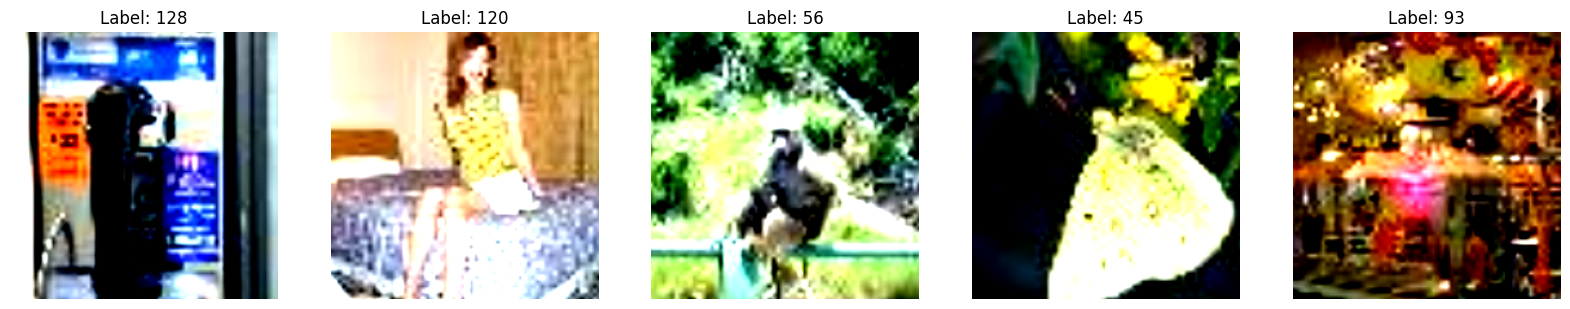

In [10]:
# Plotting the first few images in the batch
images, labels = next(iter(train_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

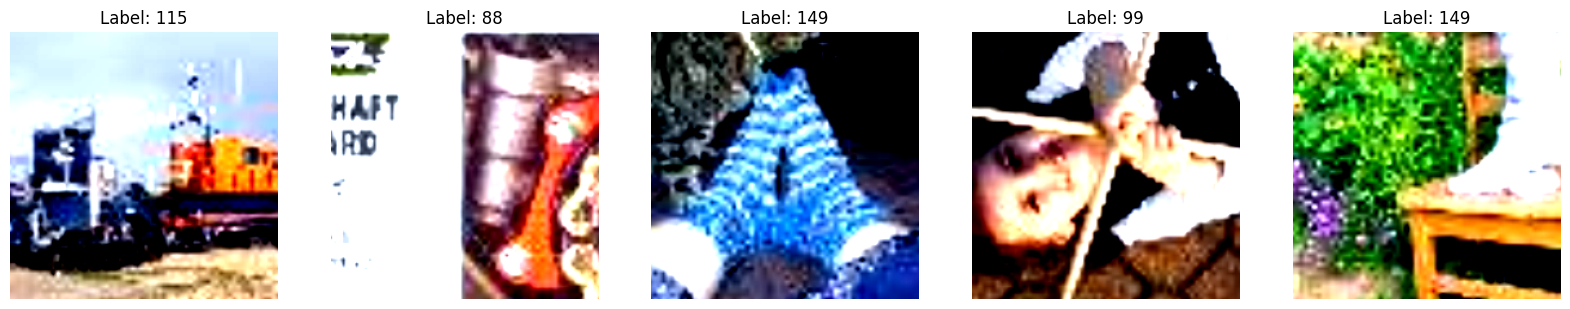

In [11]:
# Plotting the first few images in the batch
images, labels = next(iter(val_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

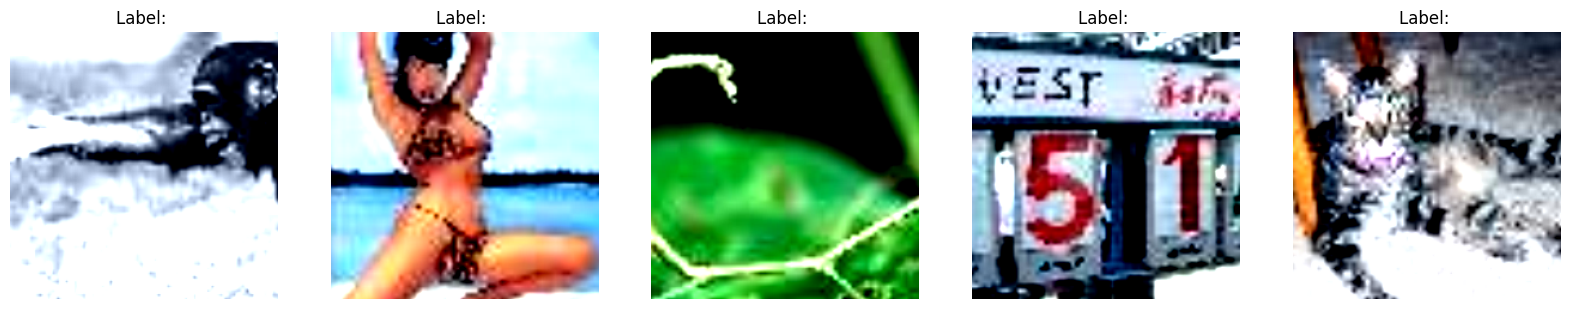

In [12]:
# Plotting the first few images in the batch
images = next(iter(test_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: ")
plt.show()

## Test Set — No Labels Available

 The test set does not include ground-truth labels. To evaluate your model
 on the test set, you need to:

 1. Run inference on the test loader to get predictions for each image
 2. Create a CSV with two columns: `File` (the image filename) and `Encoded_Label` (your predicted class)
 3. Submit that CSV for evaluation

 You can generate it like this:

 ```python
 import torch
 import pandas as pd

 model.eval()
 filenames   = test_dataset.df["File"].tolist()
 predictions = []

 with torch.inference_mode():
     for i, images in enumerate(test_loader):
         images  = images.to(device)
         logits  = model(images)
         preds   = logits.argmax(dim=1).cpu().tolist()
         predictions.extend(preds)

 submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
 submission.to_csv("submission.csv", index=False)
 print(submission.head())
 ```

 Make sure the order of `filenames` matches the order images are loaded
 by the test loader — since `shuffle=False`, the order is preserved.

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()


def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

In [14]:
torch.manual_seed(123)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = pytorch_model.to(device)

# Only pass trainable parameters to the optimizer
optimizer = torch.optim.Adam(
    pytorch_model.classifier[2].parameters(),
    lr=0.001
)
criterion = nn.CrossEntropyLoss()

train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)
val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)

writer = SummaryWriter(log_dir="logs/resnet18-transfer-frozen")

dummy = torch.zeros(1, 3, 224, 224).to(device)
writer.add_graph(model, dummy)

In [15]:
MAX_EPOCHS = 5

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)

    writer.add_scalars("Loss",     {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": tr_acc,  "val": vl_acc},  epoch)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

writer.close()

Epoch 01/5 | Train Loss: 1.1509  Acc: 0.7472 | Val Loss: 0.7297  Acc: 0.8028
Epoch 02/5 | Train Loss: 0.6790  Acc: 0.8177 | Val Loss: 0.6974  Acc: 0.8130
Epoch 03/5 | Train Loss: 0.5953  Acc: 0.8372 | Val Loss: 0.6978  Acc: 0.8155
Epoch 04/5 | Train Loss: 0.5446  Acc: 0.8480 | Val Loss: 0.7084  Acc: 0.8148
Epoch 05/5 | Train Loss: 0.5054  Acc: 0.8589 | Val Loss: 0.7173  Acc: 0.8133


In [16]:
import torch
import pandas as pd

pytorch_model.eval()
filenames   = test_dataset.df["File"].tolist()
predictions = []

with torch.inference_mode():
    for i, images in enumerate(test_loader):
        images  = images.to(device)
        logits  = pytorch_model(images)
        preds   = logits.argmax(dim=1).cpu().tolist()
        predictions.extend(preds)

submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
submission.to_csv("submission.csv", index=False)
print(submission.head())

            File  Encoded_Label
0  val_9240.JPEG             55
1  val_9308.JPEG             74
2  val_3262.JPEG             40
3  val_3528.JPEG             86
4  val_4147.JPEG             32
